In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [4]:
# -----------------------------------------------------------------------------
# Config / provenance
# -----------------------------------------------------------------------------

BASELINE_EXPERIMENT = "base_plus_engineered_hole"
BASELINE_MODEL_VERSION = "v1_catboost_expected_strokes_base_plus_engineered_hole"

RESIDUALS_PATH = Path.cwd() / "notebook_exports" / "catboost_expected_strokes_residuals_v1.parquet"
OUTPUT_DIR = Path.cwd() / "notebook_exports"
OUTPUT_DIR.mkdir(exist_ok=True)

WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]
WIND_GUST_ORDER = ["low", "mild", "high", "very_high"]
DIVISION_ORDER = ["MA4", "MA3", "MA2", "MA1", "MPO"]

print("Using baseline residual input:", RESIDUALS_PATH)
print("Baseline experiment:", BASELINE_EXPERIMENT)
print("Baseline model version:", BASELINE_MODEL_VERSION)



Using baseline residual input: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\catboost_expected_strokes_residuals_v1.parquet
Baseline experiment: base_plus_engineered_hole
Baseline model version: v1_catboost_expected_strokes_base_plus_engineered_hole


In [6]:
# -----------------------------------------------------------------------------
# Load scored residual dataset from the selected expected-strokes baseline
# -----------------------------------------------------------------------------

residuals_df = pd.read_parquet(RESIDUALS_PATH)

print("Residual dataframe shape:", residuals_df.shape)
residuals_df.head()



Residual dataframe shape: (1564744, 27)


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed
0,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,4,FPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.296190,-0.296190,0.296190,catboost,prototype_v1,11
1,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.684867,-0.684867,0.684867,catboost,prototype_v1,11
2,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,4,MA40,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.129436,-0.129436,0.129436,catboost,prototype_v1,11
3,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,4,MA2,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.132211,-0.132211,0.132211,catboost,prototype_v1,11
4,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.982817,1.017183,1.017183,catboost,prototype_v1,11


In [7]:
# -----------------------------------------------------------------------------
# Validate required columns
# -----------------------------------------------------------------------------

required_cols = [
    "tourn_id",
    "round_number",
    "hole_number",
    "player_key",
    "actual_strokes",
    "expected_strokes",
    "residual_strokes",
    "player_rating",
    "course_id",
    "hole_length",
    "hole_par",
    "division",
    "wind_speed_mps",
    "wind_gust_mps",
    "wind_dir_deg",
    "temp_c",
    "precip_mm",
]

missing = [c for c in required_cols if c not in residuals_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns are present.")


All required columns are present.


In [8]:
# -----------------------------------------------------------------------------
# Wind feature engineering
# -----------------------------------------------------------------------------

def wind_speed_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 2.0:
        return "calm"
    if speed < 5.0:
        return "light"
    if speed < 8.0:
        return "moderate"
    if speed < 12.0:
        return "strong"
    return "very_strong"


def wind_gust_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 3.0:
        return "low"
    if speed < 6.0:
        return "mild"
    if speed < 10.0:
        return "high"
    return "very_high"


def wind_dir_sector(deg: float | None) -> str:
    if pd.isna(deg):
        return "unknown"
    deg = float(deg) % 360.0
    if deg < 45 or deg >= 315:
        return "N"
    if deg < 135:
        return "E"
    if deg < 225:
        return "S"
    return "W"


model_df = residuals_df.copy()

model_df["wind_speed_bucket"] = model_df["wind_speed_mps"].apply(wind_speed_bucket)
model_df["wind_gust_bucket"] = model_df["wind_gust_mps"].apply(wind_gust_bucket)
model_df["wind_dir_sector"] = model_df["wind_dir_deg"].apply(wind_dir_sector)

model_df["hole_length_bin"] = pd.qcut(model_df["hole_length"], q=10, duplicates="drop")
model_df["player_rating_bin"] = pd.qcut(model_df["player_rating"], q=10, duplicates="drop")

# A few simple interaction-friendly features
model_df["wind_x_hole_length"] = model_df["wind_speed_mps"] * model_df["hole_length"]
model_df["gust_x_hole_length"] = model_df["wind_gust_mps"] * model_df["hole_length"]
model_df["wind_x_player_rating"] = model_df["wind_speed_mps"] * model_df["player_rating"]

print(model_df.shape)
model_df.head()


(1564744, 34)


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed,wind_gust_bucket,wind_dir_sector,hole_length_bin,player_rating_bin,wind_x_hole_length,gust_x_hole_length,wind_x_player_rating
0,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,4,FPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.296190,-0.296190,0.296190,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(910.0, 924.0]",854.9,2060.0,1512.26
1,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.684867,-0.684867,0.684867,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(961.0, 1059.0]",854.9,2060.0,1655.02
2,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,4,MA40,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.129436,-0.129436,0.129436,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(924.0, 940.0]",854.9,2060.0,1543.80
3,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,4,MA2,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.132211,-0.132211,0.132211,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(910.0, 924.0]",854.9,2060.0,1530.52
4,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.982817,1.017183,1.017183,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(940.0, 961.0]",854.9,2060.0,1585.30


In [9]:
# -----------------------------------------------------------------------------
# Filter modeling rows
# -----------------------------------------------------------------------------
# We only keep rows where the wind/weather values needed for modeling exist.
# -----------------------------------------------------------------------------

wind_model_df = model_df.dropna(
    subset=[
        "residual_strokes",
        "wind_speed_mps",
        "wind_gust_mps",
        "wind_dir_deg",
        "temp_c",
        "precip_mm",
        "hole_length",
        "player_rating",
        "hole_par",
        "course_id",
    ]
).copy()

wind_model_df["division"] = wind_model_df["division"].astype("string")
wind_model_df["hole_par"] = wind_model_df["hole_par"].astype("string")
wind_model_df["course_id"] = wind_model_df["course_id"].astype("string")
wind_model_df["wind_speed_bucket"] = wind_model_df["wind_speed_bucket"].astype("string")
wind_model_df["wind_gust_bucket"] = wind_model_df["wind_gust_bucket"].astype("string")
wind_model_df["wind_dir_sector"] = wind_model_df["wind_dir_sector"].astype("string")

print("Wind modeling frame shape:", wind_model_df.shape)


Wind modeling frame shape: (1564744, 34)


In [10]:
# -----------------------------------------------------------------------------
# Use the existing held-out events only; no new split is needed.
# -----------------------------------------------------------------------------
# The residual dataset is already from the held-out test side of the winning
# expected-strokes model. For this prototype, we split those held-out rows into
# a second-stage train/validation set by tournament again.
# -----------------------------------------------------------------------------

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
groups = wind_model_df["tourn_id"].astype(int)

train_idx, test_idx = next(splitter.split(wind_model_df, groups=groups))

wind_train_df = wind_model_df.iloc[train_idx].copy()
wind_test_df = wind_model_df.iloc[test_idx].copy()

train_events = set(wind_train_df["tourn_id"].astype(int).unique())
test_events = set(wind_test_df["tourn_id"].astype(int).unique())
assert train_events.isdisjoint(test_events)

print("Wind stage train rows:", len(wind_train_df))
print("Wind stage test rows:", len(wind_test_df))
print("Wind stage train events:", len(train_events))
print("Wind stage test events:", len(test_events))


Wind stage train rows: 1155775
Wind stage test rows: 408969
Wind stage train events: 917
Wind stage test events: 306


In [11]:
# -----------------------------------------------------------------------------
# Modeling target
# -----------------------------------------------------------------------------

target_col = "residual_strokes"

print(wind_train_df[target_col].describe())


count    1.155775e+06
mean     5.147657e-03
std      7.927817e-01
min     -4.451049e+00
25%     -5.324549e-01
50%     -5.460031e-02
75%      3.600895e-01
max      1.053214e+01
Name: residual_strokes, dtype: float64


In [12]:
# -----------------------------------------------------------------------------
# Model 1: linear benchmark
# -----------------------------------------------------------------------------

linear_numeric_features = [
    "wind_speed_mps",
    "wind_gust_mps",
    "wind_dir_deg",
    "temp_c",
    "precip_mm",
    "hole_length",
    "player_rating",
    "wind_x_hole_length",
    "gust_x_hole_length",
    "wind_x_player_rating",
]

linear_categorical_features = [
    "hole_par",
    "division",
    "wind_speed_bucket",
    "wind_gust_bucket",
    "wind_dir_sector",
]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            linear_numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            linear_categorical_features,
        ),
    ],
    remainder="drop",
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]
)

linear_model.fit(
    wind_train_df[linear_numeric_features + linear_categorical_features],
    wind_train_df[target_col],
)

linear_pred = linear_model.predict(
    wind_test_df[linear_numeric_features + linear_categorical_features]
)


In [13]:
# -----------------------------------------------------------------------------
# Model 2: CatBoost wind-effect model
# -----------------------------------------------------------------------------

cb_numeric_features = [
    "wind_speed_mps",
    "wind_gust_mps",
    "wind_dir_deg",
    "temp_c",
    "precip_mm",
    "hole_length",
    "player_rating",
    "wind_x_hole_length",
    "gust_x_hole_length",
    "wind_x_player_rating",
]

cb_categorical_features = [
    "hole_par",
    "course_id",
    "division",
    "wind_speed_bucket",
    "wind_gust_bucket",
    "wind_dir_sector",
]

cb_feature_cols = cb_numeric_features + cb_categorical_features

cb_train = wind_train_df.copy()
cb_test = wind_test_df.copy()

for col in cb_categorical_features:
    cb_train[col] = cb_train[col].astype("string").fillna("__MISSING__").astype(str)
    cb_test[col] = cb_test[col].astype("string").fillna("__MISSING__").astype(str)

    train_levels = set(cb_train[col].unique())
    cb_test[col] = cb_test[col].where(cb_test[col].isin(train_levels), "__MISSING__")

for col in cb_numeric_features + [target_col]:
    cb_train[col] = pd.to_numeric(cb_train[col], errors="coerce")
    cb_test[col] = pd.to_numeric(cb_test[col], errors="coerce")

cb_train = cb_train.dropna(subset=cb_numeric_features + [target_col]).copy()
cb_test = cb_test.dropna(subset=cb_numeric_features + [target_col]).copy()

cat_idx = [cb_feature_cols.index(c) for c in cb_categorical_features]

train_pool = Pool(
    data=cb_train[cb_feature_cols],
    label=cb_train[target_col],
    cat_features=cat_idx,
)

test_pool = Pool(
    data=cb_test[cb_feature_cols],
    label=cb_test[target_col],
    cat_features=cat_idx,
)

WIND_CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 800,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": 42,
    "verbose": 100,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

wind_catboost_model = CatBoostRegressor(**WIND_CATBOOST_PARAMS)
wind_catboost_model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    early_stopping_rounds=100,
)

catboost_pred = wind_catboost_model.predict(test_pool)


0:	learn: 0.7922384	test: 0.7993101	best: 0.7993101 (0)	total: 1.53s	remaining: 20m 21s
100:	learn: 0.7837556	test: 0.7968145	best: 0.7967239 (93)	total: 1m	remaining: 6m 58s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7967238935
bestIteration = 93

Shrink model to first 94 iterations.


In [14]:
# -----------------------------------------------------------------------------
# Evaluation helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }

linear_metrics = regression_metrics(wind_test_df[target_col], linear_pred)
catboost_metrics = regression_metrics(cb_test[target_col], catboost_pred)

wind_model_metrics_df = pd.DataFrame(
    [
        {"model": "ridge_residual_model", **linear_metrics},
        {"model": "catboost_residual_model", **catboost_metrics},
    ]
).sort_values(["rmse", "mae"], ascending=[True, True]).reset_index(drop=True)

wind_model_metrics_df


,model,mae,rmse,r2
0,catboost_residual_model,0.591081,0.796724,0.006995
1,ridge_residual_model,0.591235,0.798029,0.003739


In [15]:
# -----------------------------------------------------------------------------
# Build scored outputs from the winning second-stage model
# -----------------------------------------------------------------------------

WINNING_WIND_MODEL = wind_model_metrics_df.iloc[0]["model"]
print("Winning wind model:", WINNING_WIND_MODEL)

if WINNING_WIND_MODEL == "catboost_residual_model":
    scored_df = cb_test.copy()
    scored_df["predicted_wind_residual"] = catboost_pred
else:
    scored_df = wind_test_df.copy()
    scored_df["predicted_wind_residual"] = linear_pred

scored_df["wind_model_error"] = scored_df["residual_strokes"] - scored_df["predicted_wind_residual"]
scored_df["abs_wind_model_error"] = scored_df["wind_model_error"].abs()

scored_df.head()


Winning wind model: catboost_residual_model


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed,wind_gust_bucket,wind_dir_sector,hole_length_bin,player_rating_bin,wind_x_hole_length,gust_x_hole_length,wind_x_player_rating,predicted_wind_residual,wind_model_error,abs_wind_model_error
12549,2025,90069,1,1,PDGA#119740,5,2,813.0,__MISSING__,225.0,3,MA3,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,3.210408,1.789592,1.789592,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(806.0, 842.0]",1289.25,2857.5,4658.49,0.067111,1.722481,1.722481
12550,2025,90069,1,1,PDGA#119743,2,-1,881.0,__MISSING__,225.0,3,MA50,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.955322,-0.955322,0.955322,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(864.0, 881.0]",1289.25,2857.5,5048.13,0.049141,-1.004463,1.004463
12551,2025,90069,1,1,PDGA#129468,3,0,924.0,__MISSING__,225.0,3,MP40,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.813975,0.186025,0.186025,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(910.0, 924.0]",1289.25,2857.5,5294.52,0.039625,0.146400,0.146400
12552,2025,90069,1,1,PDGA#138908,3,0,835.0,__MISSING__,225.0,3,MA3,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,3.110443,-0.110443,0.110443,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(806.0, 842.0]",1289.25,2857.5,4784.55,0.064657,-0.175101,0.175101
12553,2025,90069,1,1,PDGA#145164,4,1,916.0,__MISSING__,225.0,3,MA40,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.816579,1.183421,1.183421,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(910.0, 924.0]",1289.25,2857.5,5248.68,0.041773,1.141648,1.141648


In [16]:
# -----------------------------------------------------------------------------
# Does predicted wind residual increase with wind bucket?
# -----------------------------------------------------------------------------

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            rows=("residual_strokes", "size"),
            actual_residual_mean=("residual_strokes", "mean"),
            predicted_residual_mean=("predicted_wind_residual", "mean"),
            wind_model_error_mean=("wind_model_error", "mean"),
            wind_model_mae=("abs_wind_model_error", "mean"),
            wind_speed_mean=("wind_speed_mps", "mean"),
            wind_gust_mean=("wind_gust_mps", "mean"),
        )
        .sort_values("rows", ascending=False)
        .reset_index(drop=True)
    )

predicted_by_wind_speed_bucket = summarize_group(scored_df, ["wind_speed_bucket"])
predicted_by_wind_gust_bucket = summarize_group(scored_df, ["wind_gust_bucket"])

predicted_by_wind_speed_bucket, predicted_by_wind_gust_bucket


(  wind_speed_bucket    rows  actual_residual_mean  predicted_residual_mean  \
 0             light  228932              0.012037                 0.017228   
 1              calm  141673             -0.027124                -0.011766   
 2          moderate   32573              0.132066                 0.093953   
 3            strong    5791              0.229851                 0.119191   
 
    wind_model_error_mean  wind_model_mae  wind_speed_mean  wind_gust_mean  
 0              -0.005191        0.585847         3.105905        6.656131  
 1              -0.015358        0.584140         1.226087        3.205588  
 2               0.038113        0.645857         6.149992       13.008307  
 3               0.110660        0.659652         8.458586       16.778208  ,
   wind_gust_bucket    rows  actual_residual_mean  predicted_residual_mean  \
 0             mild  168700             -0.013114                -0.006257   
 1             high  129698              0.024124            

In [17]:
# -----------------------------------------------------------------------------
# Group-level wind impact summaries
# -----------------------------------------------------------------------------

predicted_by_course_and_wind = summarize_group(scored_df, ["course_id", "wind_speed_bucket"])
predicted_by_division_and_wind = summarize_group(
    scored_df[scored_df["division"].isin(DIVISION_ORDER)].copy(),
    ["division", "wind_speed_bucket"],
)
predicted_by_hole_par_and_wind = summarize_group(scored_df, ["hole_par", "wind_speed_bucket"])
predicted_by_hole_length_bin_and_wind = summarize_group(scored_df, ["hole_length_bin", "wind_speed_bucket"])
predicted_by_player_rating_bin_and_wind = summarize_group(scored_df, ["player_rating_bin", "wind_speed_bucket"])

predicted_by_course_and_wind.head()


,course_id,wind_speed_bucket,rows,actual_residual_mean,predicted_residual_mean,wind_model_error_mean,wind_model_mae,wind_speed_mean,wind_gust_mean
0,__MISSING__,light,165827,0.009160,0.018975,-0.009815,0.577986,3.099948,6.568004
1,__MISSING__,calm,104355,-0.020857,-0.002491,-0.018367,0.581598,1.239521,3.209337
2,__MISSING__,moderate,14403,0.114452,0.093912,0.020540,0.637021,5.968070,12.189530
3,-1,light,13745,0.019044,0.059739,-0.040696,0.621374,3.623807,8.205107
4,25464,calm,5152,-0.132796,-0.261337,0.128542,0.588096,0.574845,1.431949


In [18]:
# -----------------------------------------------------------------------------
# Group-level wind impact summaries
# -----------------------------------------------------------------------------

predicted_by_course_and_wind = summarize_group(scored_df, ["course_id", "wind_speed_bucket"])
predicted_by_division_and_wind = summarize_group(
    scored_df[scored_df["division"].isin(DIVISION_ORDER)].copy(),
    ["division", "wind_speed_bucket"],
)
predicted_by_hole_par_and_wind = summarize_group(scored_df, ["hole_par", "wind_speed_bucket"])
predicted_by_hole_length_bin_and_wind = summarize_group(scored_df, ["hole_length_bin", "wind_speed_bucket"])
predicted_by_player_rating_bin_and_wind = summarize_group(scored_df, ["player_rating_bin", "wind_speed_bucket"])

predicted_by_course_and_wind.head()


,course_id,wind_speed_bucket,rows,actual_residual_mean,predicted_residual_mean,wind_model_error_mean,wind_model_mae,wind_speed_mean,wind_gust_mean
0,__MISSING__,light,165827,0.009160,0.018975,-0.009815,0.577986,3.099948,6.568004
1,__MISSING__,calm,104355,-0.020857,-0.002491,-0.018367,0.581598,1.239521,3.209337
2,__MISSING__,moderate,14403,0.114452,0.093912,0.020540,0.637021,5.968070,12.189530
3,-1,light,13745,0.019044,0.059739,-0.040696,0.621374,3.623807,8.205107
4,25464,calm,5152,-0.132796,-0.261337,0.128542,0.588096,0.574845,1.431949


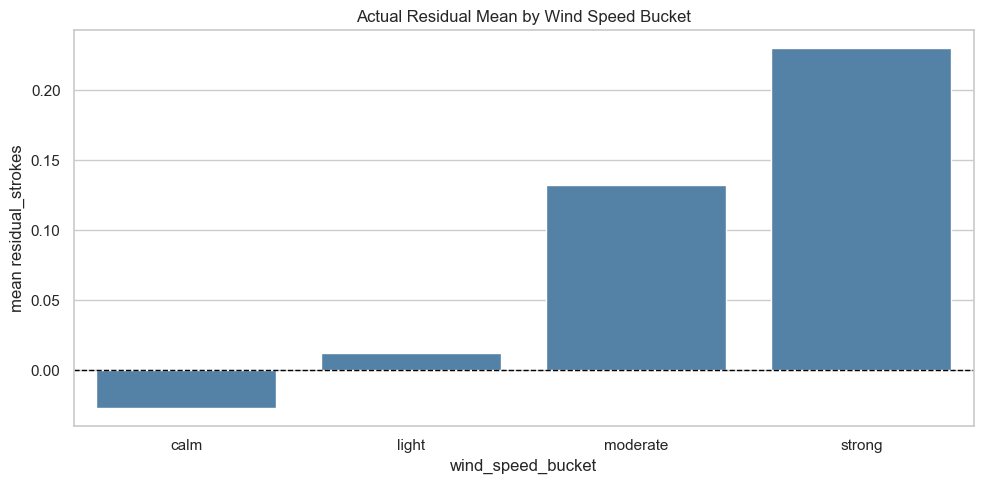

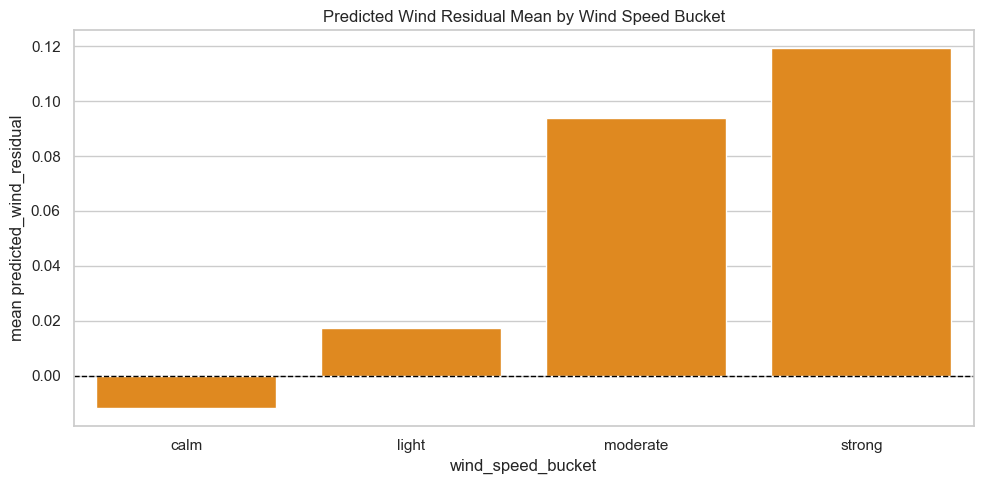

In [19]:
# -----------------------------------------------------------------------------
# Charts: actual vs predicted wind residual by wind speed bucket
# -----------------------------------------------------------------------------

speed_plot_df = predicted_by_wind_speed_bucket.copy()
speed_plot_df = speed_plot_df[speed_plot_df["wind_speed_bucket"].isin(WIND_SPEED_ORDER)].copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=speed_plot_df, x="wind_speed_bucket", y="actual_residual_mean", order=WIND_SPEED_ORDER, color="steelblue")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Actual Residual Mean by Wind Speed Bucket")
plt.xlabel("wind_speed_bucket")
plt.ylabel("mean residual_strokes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=speed_plot_df, x="wind_speed_bucket", y="predicted_residual_mean", order=WIND_SPEED_ORDER, color="darkorange")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Predicted Wind Residual Mean by Wind Speed Bucket")
plt.xlabel("wind_speed_bucket")
plt.ylabel("mean predicted_wind_residual")
plt.tight_layout()
plt.show()


In [20]:
# -----------------------------------------------------------------------------
# Round-level wind impact aggregation
# -----------------------------------------------------------------------------

wind_impact_round_df = (
    scored_df.groupby(["tourn_id", "round_number", "player_key"], as_index=False, dropna=False)
    .agg(
        course_id=("course_id", "first"),
        division=("division", "first"),
        actual_round_residual=("residual_strokes", "sum"),
        predicted_round_wind_residual=("predicted_wind_residual", "sum"),
        round_wind_model_error=("wind_model_error", "sum"),
        hole_count=("hole_number", "nunique"),
        round_wind_speed_mps_mean=("wind_speed_mps", "mean"),
        round_wind_gust_mps_mean=("wind_gust_mps", "mean"),
        round_temp_c_mean=("temp_c", "mean"),
        round_precip_mm_mean=("precip_mm", "mean"),
    )
)

wind_impact_round_df.head()


,tourn_id,round_number,player_key,course_id,division,actual_round_residual,predicted_round_wind_residual,round_wind_model_error,hole_count,round_wind_speed_mps_mean,round_wind_gust_mps_mean,round_temp_c_mean,round_precip_mm_mean
0,90069,1,PDGA#119740,__MISSING__,MA3,3.453431,2.284930,1.168501,34,5.73,12.7,26.1,0.0
1,90069,1,PDGA#119743,__MISSING__,MA50,-0.224313,1.673816,-1.898129,34,5.73,12.7,26.1,0.0
2,90069,1,PDGA#129468,__MISSING__,MP40,-7.496243,1.367936,-8.864179,34,5.73,12.7,26.1,0.0
3,90069,1,PDGA#138908,__MISSING__,MA3,9.853093,2.201491,7.651602,34,5.73,12.7,26.1,0.0
4,90069,1,PDGA#145164,__MISSING__,MA40,3.604071,1.440945,2.163126,34,5.73,12.7,26.1,0.0


In [22]:
# -----------------------------------------------------------------------------
# Richer second-stage feature engineering
# -----------------------------------------------------------------------------

wind_model_df = residuals_df.copy()

# Core wind features
wind_model_df["wind_speed_bucket"] = wind_model_df["wind_speed_mps"].apply(wind_speed_bucket)
wind_model_df["wind_gust_bucket"] = wind_model_df["wind_gust_mps"].apply(wind_gust_bucket)
wind_model_df["wind_dir_sector"] = wind_model_df["wind_dir_deg"].apply(wind_dir_sector)

# Ordered / categorical-friendly bins
wind_model_df["hole_length_bin"] = pd.qcut(wind_model_df["hole_length"], q=10, duplicates="drop")
wind_model_df["player_rating_bin"] = pd.qcut(wind_model_df["player_rating"], q=10, duplicates="drop")

# Numeric helper for interactions
wind_model_df["hole_par_num"] = pd.to_numeric(wind_model_df["hole_par"], errors="coerce")
wind_model_df["round_number_num"] = pd.to_numeric(wind_model_df["round_number"], errors="coerce")

# Interaction features
wind_model_df["wind_x_hole_length"] = wind_model_df["wind_speed_mps"] * wind_model_df["hole_length"]
wind_model_df["gust_x_hole_length"] = wind_model_df["wind_gust_mps"] * wind_model_df["hole_length"]
wind_model_df["wind_x_player_rating"] = wind_model_df["wind_speed_mps"] * wind_model_df["player_rating"]
wind_model_df["wind_x_hole_par_num"] = wind_model_df["wind_speed_mps"] * wind_model_df["hole_par_num"]
wind_model_df["gust_x_hole_par_num"] = wind_model_df["wind_gust_mps"] * wind_model_df["hole_par_num"]

# Convert interval bins to strings for CatBoost compatibility
wind_model_df["hole_length_bin_str"] = wind_model_df["hole_length_bin"].astype("string")
wind_model_df["player_rating_bin_str"] = wind_model_df["player_rating_bin"].astype("string")

# Basic cleanup
wind_model_df["division"] = wind_model_df["division"].astype("string")
wind_model_df["hole_par"] = wind_model_df["hole_par"].astype("string")
wind_model_df["course_id"] = wind_model_df["course_id"].astype("string")
wind_model_df["wind_speed_bucket"] = wind_model_df["wind_speed_bucket"].astype("string")
wind_model_df["wind_gust_bucket"] = wind_model_df["wind_gust_bucket"].astype("string")
wind_model_df["wind_dir_sector"] = wind_model_df["wind_dir_sector"].astype("string")

wind_model_df = wind_model_df.dropna(
    subset=[
        "residual_strokes",
        "wind_speed_mps",
        "wind_gust_mps",
        "wind_dir_deg",
        "temp_c",
        "precip_mm",
        "hole_length",
        "player_rating",
        "hole_par_num",
    ]
).copy()

print("Richer wind modeling frame shape:", wind_model_df.shape)
wind_model_df.head()


Richer wind modeling frame shape: (1564744, 40)


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed,wind_gust_bucket,wind_dir_sector,hole_length_bin,player_rating_bin,hole_par_num,round_number_num,wind_x_hole_length,gust_x_hole_length,wind_x_player_rating,wind_x_hole_par_num,gust_x_hole_par_num,hole_length_bin_str,player_rating_bin_str
0,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,4,FPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.296190,-0.296190,0.296190,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(910.0, 924.0]",4,1,854.9,2060.0,1512.26,6.64,16.0,"(463.0, 1251.0]","(910.0, 924.0]"
1,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.684867,-0.684867,0.684867,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(961.0, 1059.0]",4,1,854.9,2060.0,1655.02,6.64,16.0,"(463.0, 1251.0]","(961.0, 1059.0]"
2,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,4,MA40,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.129436,-0.129436,0.129436,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(924.0, 940.0]",4,1,854.9,2060.0,1543.80,6.64,16.0,"(463.0, 1251.0]","(924.0, 940.0]"
3,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,4,MA2,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.132211,-0.132211,0.132211,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(910.0, 924.0]",4,1,854.9,2060.0,1530.52,6.64,16.0,"(463.0, 1251.0]","(910.0, 924.0]"
4,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.982817,1.017183,1.017183,catboost,prototype_v1,11,mild,W,"(463.0, 1251.0]","(940.0, 961.0]",4,1,854.9,2060.0,1585.30,6.64,16.0,"(463.0, 1251.0]","(940.0, 961.0]"


In [23]:
# -----------------------------------------------------------------------------
# Split the wind-stage modeling frame by tournament again
# -----------------------------------------------------------------------------

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
groups = wind_model_df["tourn_id"].astype(int)

train_idx, test_idx = next(splitter.split(wind_model_df, groups=groups))

wind_train_df = wind_model_df.iloc[train_idx].copy()
wind_test_df = wind_model_df.iloc[test_idx].copy()

train_events = set(wind_train_df["tourn_id"].astype(int).unique())
test_events = set(wind_test_df["tourn_id"].astype(int).unique())
assert train_events.isdisjoint(test_events)

print("Wind-stage train rows:", len(wind_train_df))
print("Wind-stage test rows:", len(wind_test_df))
print("Train events:", len(train_events))
print("Test events:", len(test_events))

Wind-stage train rows: 1155775
Wind-stage test rows: 408969
Train events: 917
Test events: 306


In [24]:
# -----------------------------------------------------------------------------
# Second-stage experiment definitions
# -----------------------------------------------------------------------------

SECOND_STAGE_EXPERIMENTS = [
    {
        "name": "wind_core",
        "numeric": [
            "wind_speed_mps",
            "wind_gust_mps",
            "wind_dir_deg",
            "temp_c",
            "precip_mm",
        ],
        "categorical": [
            "wind_speed_bucket",
            "wind_gust_bucket",
            "wind_dir_sector",
        ],
    },
    {
        "name": "wind_plus_context",
        "numeric": [
            "wind_speed_mps",
            "wind_gust_mps",
            "wind_dir_deg",
            "temp_c",
            "precip_mm",
            "hole_length",
            "player_rating",
            "round_number_num",
        ],
        "categorical": [
            "hole_par",
            "course_id",
            "division",
            "wind_speed_bucket",
            "wind_gust_bucket",
            "wind_dir_sector",
        ],
    },
    {
        "name": "wind_plus_context_plus_interactions",
        "numeric": [
            "wind_speed_mps",
            "wind_gust_mps",
            "wind_dir_deg",
            "temp_c",
            "precip_mm",
            "hole_length",
            "player_rating",
            "round_number_num",
            "hole_par_num",
            "wind_x_hole_length",
            "gust_x_hole_length",
            "wind_x_player_rating",
            "wind_x_hole_par_num",
            "gust_x_hole_par_num",
        ],
        "categorical": [
            "hole_par",
            "course_id",
            "division",
            "wind_speed_bucket",
            "wind_gust_bucket",
            "wind_dir_sector",
            "hole_length_bin_str",
            "player_rating_bin_str",
        ],
    },
]

In [25]:
# -----------------------------------------------------------------------------
# Second-stage CatBoost training helper
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def train_second_stage_catboost(train_df: pd.DataFrame, test_df: pd.DataFrame, experiment: dict):
    numeric_cols = [c for c in experiment["numeric"] if c in train_df.columns]
    categorical_cols = [c for c in experiment["categorical"] if c in train_df.columns]

    feature_cols = numeric_cols + categorical_cols

    fit_train = train_df.copy()
    fit_test = test_df.copy()

    for col in numeric_cols + ["residual_strokes"]:
        fit_train[col] = pd.to_numeric(fit_train[col], errors="coerce")
        fit_test[col] = pd.to_numeric(fit_test[col], errors="coerce")

    fit_train = fit_train.dropna(subset=numeric_cols + ["residual_strokes"]).copy()
    fit_test = fit_test.dropna(subset=numeric_cols + ["residual_strokes"]).copy()

    for col in categorical_cols:
        fit_train[col] = fit_train[col].astype("string").fillna("__MISSING__").astype(str)
        fit_test[col] = fit_test[col].astype("string").fillna("__MISSING__").astype(str)

        train_levels = set(fit_train[col].unique())
        fit_test[col] = fit_test[col].where(fit_test[col].isin(train_levels), "__MISSING__")

    cat_idx = [feature_cols.index(c) for c in categorical_cols]

    train_pool = Pool(
        data=fit_train[feature_cols],
        label=fit_train["residual_strokes"],
        cat_features=cat_idx,
    )
    test_pool = Pool(
        data=fit_test[feature_cols],
        label=fit_test["residual_strokes"],
        cat_features=cat_idx,
    )

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=800,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5.0,
        random_seed=42,
        verbose=100,
        bootstrap_type="Bernoulli",
        subsample=0.8,
        max_ctr_complexity=1,
        store_all_simple_ctr=False,
        task_type="CPU",
    )

    model.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True,
        early_stopping_rounds=100,
    )

    pred = model.predict(test_pool)

    metrics = regression_metrics(fit_test["residual_strokes"], pred)
    metrics["best_iteration"] = getattr(model, "best_iteration_", None)
    metrics["feature_count"] = len(feature_cols)

    scored = fit_test.copy()
    scored["predicted_wind_residual"] = pred
    scored["wind_model_error"] = scored["residual_strokes"] - scored["predicted_wind_residual"]
    scored["abs_wind_model_error"] = scored["wind_model_error"].abs()

    return model, scored, metrics

In [26]:
# -----------------------------------------------------------------------------
# Run richer second-stage experiments
# -----------------------------------------------------------------------------

second_stage_results = []
second_stage_scored = {}

for experiment in SECOND_STAGE_EXPERIMENTS:
    print(f"Running second-stage experiment: {experiment['name']}")
    model, scored_df, metrics = train_second_stage_catboost(wind_train_df, wind_test_df, experiment)
    metrics["experiment"] = experiment["name"]
    second_stage_results.append(metrics)
    second_stage_scored[experiment["name"]] = scored_df

second_stage_results_df = (
    pd.DataFrame(second_stage_results)
    .sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
    .reset_index(drop=True)
)

second_stage_results_df

Running second-stage experiment: wind_core
0:	learn: 0.7926373	test: 0.7994323	best: 0.7994323 (0)	total: 297ms	remaining: 3m 57s
100:	learn: 0.7888562	test: 0.7984483	best: 0.7983595 (69)	total: 30.5s	remaining: 3m 30s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7983595096
bestIteration = 69

Shrink model to first 70 iterations.
Running second-stage experiment: wind_plus_context
0:	learn: 0.7922390	test: 0.7993187	best: 0.7993187 (0)	total: 520ms	remaining: 6m 55s
100:	learn: 0.7839446	test: 0.7964312	best: 0.7964312 (100)	total: 39.2s	remaining: 4m 31s
200:	learn: 0.7818363	test: 0.7966223	best: 0.7963983 (105)	total: 1m 18s	remaining: 3m 53s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7963983025
bestIteration = 105

Shrink model to first 106 iterations.
Running second-stage experiment: wind_plus_context_plus_interactions
0:	learn: 0.7922330	test: 0.7993143	best: 0.7993143 (0)	total: 638ms	remaining: 8m 29s
100:	learn: 0.7837482	test:

,mae,rmse,r2,best_iteration,feature_count,experiment
0,0.591172,0.796337,0.007959,105,22,wind_plus_context_plus_interactions
1,0.591001,0.796398,0.007807,105,14,wind_plus_context
2,0.590705,0.798360,0.002914,69,8,wind_core


In [27]:
# -----------------------------------------------------------------------------
# Pick best richer second-stage model
# -----------------------------------------------------------------------------

best_second_stage_experiment = second_stage_results_df.iloc[0]["experiment"]
print("Best second-stage experiment:", best_second_stage_experiment)

best_wind_scored_df = second_stage_scored[best_second_stage_experiment].copy()
best_wind_scored_df.head()

Best second-stage experiment: wind_plus_context_plus_interactions


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed,wind_gust_bucket,wind_dir_sector,hole_length_bin,player_rating_bin,hole_par_num,round_number_num,wind_x_hole_length,gust_x_hole_length,wind_x_player_rating,wind_x_hole_par_num,gust_x_hole_par_num,hole_length_bin_str,player_rating_bin_str,predicted_wind_residual,wind_model_error,abs_wind_model_error
12549,2025,90069,1,1,PDGA#119740,5,2,813.0,__MISSING__,225.0,3,MA3,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,3.210408,1.789592,1.789592,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(806.0, 842.0]",3,1,1289.25,2857.5,4658.49,17.19,38.1,"(215.0, 243.0]","(806.0, 842.0]",0.073253,1.716339,1.716339
12550,2025,90069,1,1,PDGA#119743,2,-1,881.0,__MISSING__,225.0,3,MA50,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.955322,-0.955322,0.955322,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(864.0, 881.0]",3,1,1289.25,2857.5,5048.13,17.19,38.1,"(215.0, 243.0]","(864.0, 881.0]",0.055805,-1.011126,1.011126
12551,2025,90069,1,1,PDGA#129468,3,0,924.0,__MISSING__,225.0,3,MP40,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.813975,0.186025,0.186025,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(910.0, 924.0]",3,1,1289.25,2857.5,5294.52,17.19,38.1,"(215.0, 243.0]","(910.0, 924.0]",0.048817,0.137208,0.137208
12552,2025,90069,1,1,PDGA#138908,3,0,835.0,__MISSING__,225.0,3,MA3,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,3.110443,-0.110443,0.110443,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(806.0, 842.0]",3,1,1289.25,2857.5,4784.55,17.19,38.1,"(215.0, 243.0]","(806.0, 842.0]",0.066501,-0.176945,0.176945
12553,2025,90069,1,1,PDGA#145164,4,1,916.0,__MISSING__,225.0,3,MA40,True,moderate,5.73,12.7,196.0,26.1,0.0,999.9,15.0,2.816579,1.183421,1.183421,catboost,prototype_v1,11,very_high,S,"(215.0, 243.0]","(910.0, 924.0]",3,1,1289.25,2857.5,5248.68,17.19,38.1,"(215.0, 243.0]","(910.0, 924.0]",0.049964,1.133457,1.133457


In [28]:
# -----------------------------------------------------------------------------
# Check actual vs predicted by wind speed bucket for best richer model
# -----------------------------------------------------------------------------

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            rows=("residual_strokes", "size"),
            actual_residual_mean=("residual_strokes", "mean"),
            predicted_residual_mean=("predicted_wind_residual", "mean"),
            wind_model_error_mean=("wind_model_error", "mean"),
            wind_model_mae=("abs_wind_model_error", "mean"),
        )
        .sort_values("rows", ascending=False)
        .reset_index(drop=True)
    )

best_by_wind_speed = summarize_group(best_wind_scored_df, ["wind_speed_bucket"])
best_by_wind_speed

,wind_speed_bucket,rows,actual_residual_mean,predicted_residual_mean,wind_model_error_mean,wind_model_mae
0,light,228932,0.012037,0.018522,-0.006485,0.586040
1,calm,141673,-0.027124,-0.012076,-0.015048,0.583855
2,moderate,32573,0.132066,0.098632,0.033434,0.646452
3,strong,5791,0.229851,0.139778,0.090073,0.662124


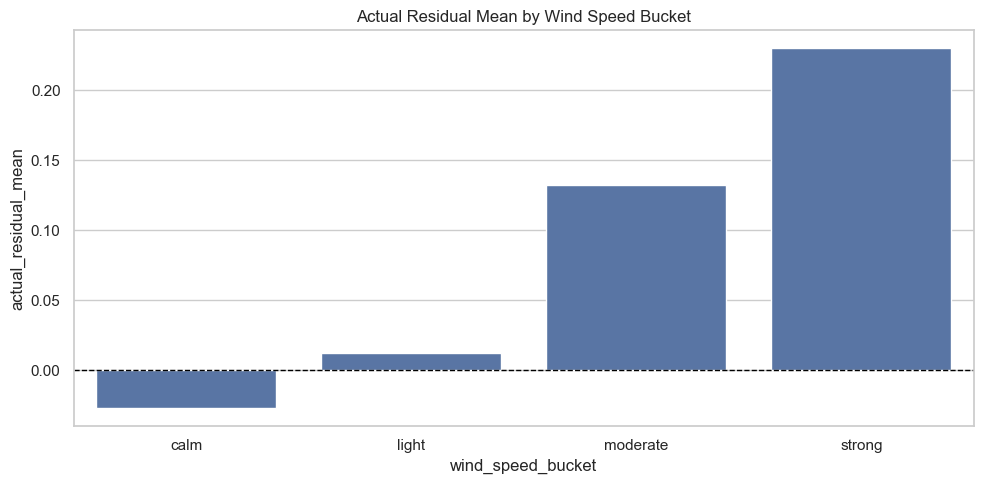

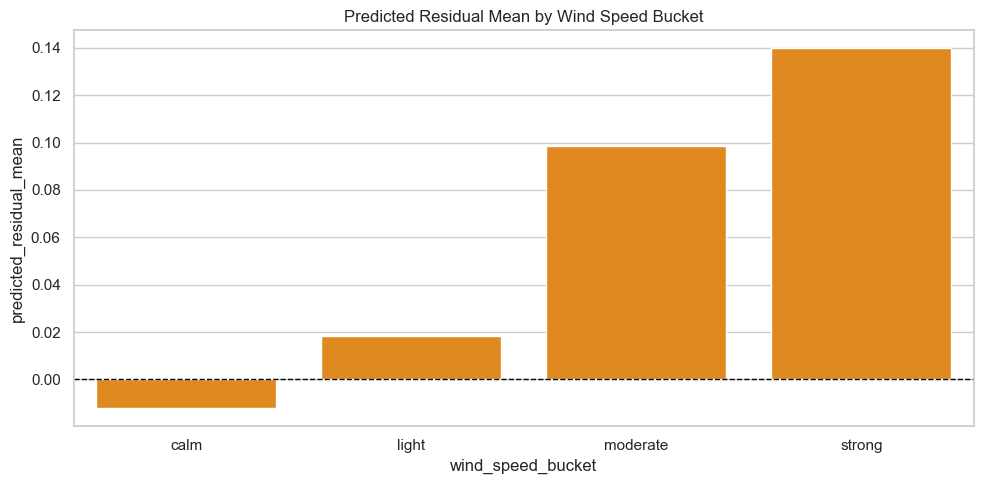

In [29]:
# -----------------------------------------------------------------------------
# Plot actual vs predicted by wind speed bucket for best richer model
# -----------------------------------------------------------------------------

WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]

plot_df = best_by_wind_speed.copy()
plot_df = plot_df[plot_df["wind_speed_bucket"].isin(WIND_SPEED_ORDER)].copy()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="wind_speed_bucket",
    y="actual_residual_mean",
    order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Actual Residual Mean by Wind Speed Bucket")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="wind_speed_bucket",
    y="predicted_residual_mean",
    order=WIND_SPEED_ORDER,
    color="darkorange",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Predicted Residual Mean by Wind Speed Bucket")
plt.tight_layout()
plt.show()
